# GPGN268 - Geophysical Data Analysis
## Data Story 02 - Global Warming

**Student:** Cooper Carlson

**Collaborators:** none

**Date:** April 24, 2026
```

### Part I: Introducing your story

Argo floats are free-floating metrology devices in the oceans. They float up and down with water columns, measuring temperature, salinity, and velocity at all times. There have been more than 3000 floats in the oceans since 2007. The floats are dispersed all across the world and provide a broad sense of the ocean's "vitals" to provide evidence for long-term effects like climate change.

We will primarily analyze temperature and salinity alongside positional data from the floats. We can tell where warm and cold ocean fluctuations have occurred historically, then attribute that information to things like global warming and seasonal trends.

The data from each individual float is spatial data over time. The three primary measurements that each float makes are attributed to the float's location at the time of each measurement. We use this to identify spatial and temporal trends.

The common tools used to analyze these types of data fall under the umbrella of computational statistical analysis. In this notebook, we demonstrate the use of Python libraries to perform data analysis and generate figures.

## Part II: Float Analysis
### Task 2.1- Reading and processing float data

In [2]:
import numpy as np
import xarray as xr
from matplotlib import pyplot as plt

import cartopy.crs as ccrs

In [3]:
def read_float_data(path):
    # Load the data
    ds_raw = xr.load_dataset(path)
    # List of variables that we will use
    variables = ['TEMP_ADJUSTED','PSAL_ADJUSTED',
                'LATITUDE', 'LONGITUDE', 'JULD']
    # Select only these variables from the whole dataset
    ds = ds_raw[variables]
    # Rename the variable 'JULD' to 'time' and make time a dimension
    # (inplace of 'N_PROF') 
    ds = ds.rename({'JULD':'time'}).swap_dims({'N_PROF':'time'})
    # Change variable names to names that are cleaner and easier to type
    ds = ds.rename({'TEMP_ADJUSTED':'temperature',
                    'PSAL_ADJUSTED':'salinity',
                    'LATITUDE':'latitude',
                    'LONGITUDE':'longitude'})
    # Defining a common pressure coordinate based on the average
    # pressure at each level accross all profiles
    mean_pressure = ds_raw.PRES_ADJUSTED.mean(dim='N_PROF')
    # Create a new variable "pressure" in the dataset and specify the units
    ds['pressure'] = mean_pressure
    ds['pressure'].attrs['units'] = 'dbar'
    # Make "pressure" on of the dimensions (inplace of 'N_LEVELS')
    ds = ds.swap_dims({'N_LEVELS':'pressure'})
    return ds

### Task 2.2- Visualizing float temperature and salinity sections

<>:12: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:12: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
/tmp/ipykernel_2912/809276224.py:12: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  label='Temperature [$\degree$ C]',


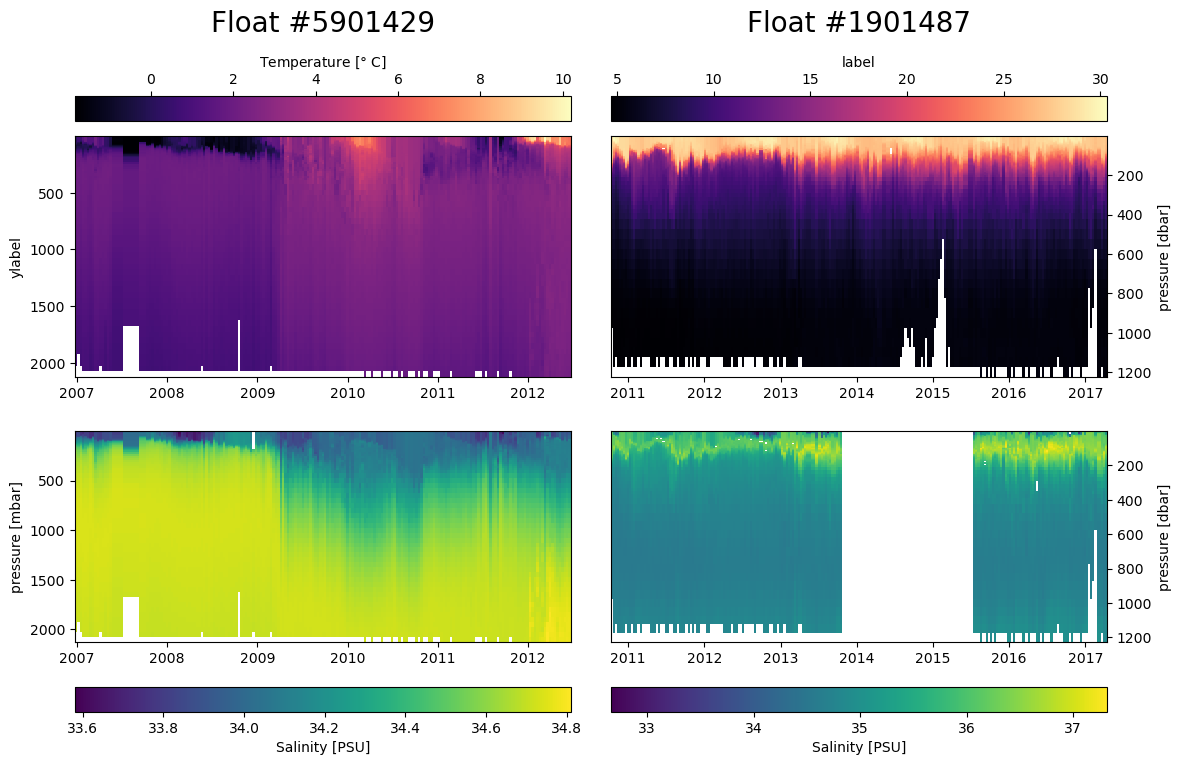

In [4]:
ds29 = read_float_data("/home/cjcin/GPGN268/coursework-carlson/ds02-global-warming/1901487_prof.nc")
ds87 = read_float_data("/home/cjcin/GPGN268/coursework-carlson/ds02-global-warming/5901429_prof.nc")

fig, axes = plt.subplots(2, 2, figsize=(12,8))
[ax1, ax2, ax3, ax4] = axes.flatten()
# Note you will need to transpose the temperature (using .T) to plot
cs1 = ax1.pcolormesh(ds87.time, ds87.pressure, ds87.temperature.T, cmap='magma')
ax1.invert_yaxis()
ax1.set_ylabel('ylabel')
ax1.set_title("Float #5901429", y=1.4, fontsize=20)
cbar1 = plt.colorbar(cs1, ax=ax1,
                     label='Temperature [$\degree$ C]',
                     orientation='horizontal',
                     location = 'top')

cs2 = ax2.pcolormesh(ds29.time, ds29.pressure, ds29.temperature.T, cmap='magma')
ax2.invert_yaxis()
ax2.set_ylabel('pressure [dbar]')
ax2.yaxis.tick_right()
ax2.yaxis.set_label_position("right")
ax2.set_title("Float #1901487", y=1.4, fontsize=20)
cbar2 = plt.colorbar(cs2, ax=ax2,
                     label='label',
                     orientation='horizontal',
                     location = 'top')

cs3 = ax3.pcolormesh(ds87.time, ds87.pressure, ds87.salinity.T, cmap='viridis')
ax3.invert_yaxis()
ax3.set_ylabel('pressure [mbar]')
cbar3 = plt.colorbar(cs3, ax=ax3,
                     label='Salinity [PSU]',
                     orientation='horizontal',
                     location = 'bottom')

cs4 = ax4.pcolormesh(ds29.time, ds29.pressure, ds29.salinity.T, cmap='viridis')
ax4.invert_yaxis()
ax4.set_ylabel('pressure [dbar]')
ax4.yaxis.tick_right()
ax4.yaxis.set_label_position("right")
cbar4 = plt.colorbar(cs4, ax=ax4,
                     label='Salinity [PSU]',
                     orientation='horizontal',
                     location = 'bottom')

fig.subplots_adjust(
    left=0.07,
    right=0.93,
    bottom=0.08,
    top=0.90,
    wspace=0.08,
    hspace=0.18
)

### Task 2.3- Float Trajectories

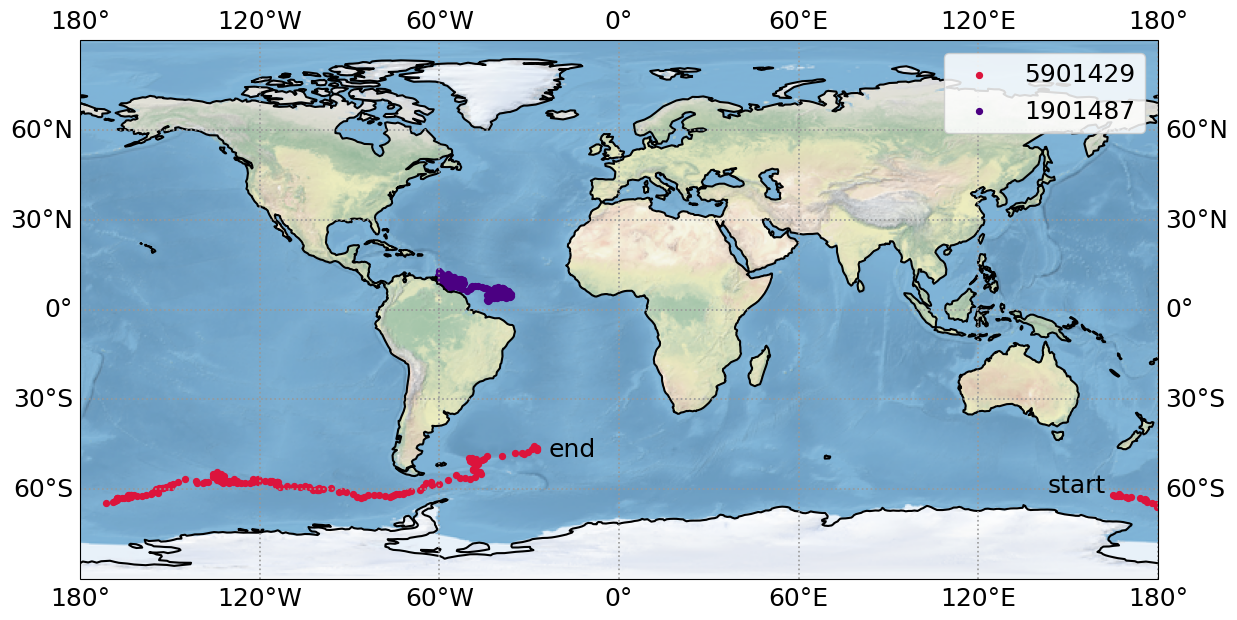

In [5]:
long87 = ds87.longitude
lat87 = ds87.latitude

long29 = ds29.longitude
lat29 = ds29.latitude

fig, ax = plt.subplots(
    figsize=(14, 7),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

ax.set_global()
ax.stock_img()
ax.coastlines(resolution='110m', color='black', linewidth=1.5)
ax.gridlines(
    draw_labels=True,
    xlocs=np.arange(-180, 181, 60),
    ylocs=np.arange(-60, 61, 30),
    linestyle=':',
    color='0.6',
    linewidth=1.2,
    xlabel_style={'size': 18},
    ylabel_style={'size': 18}
)

ax.scatter(
    long87,
    lat87,
    s=18,
    color='crimson',
    label='5901429',
    transform=ccrs.PlateCarree()
)

ax.scatter(
    long29,
    lat29,
    s=18,
    color='indigo',
    label='1901487',
    transform=ccrs.PlateCarree()
)

ax.text(
    long87[0] - 22,
    lat87[0] + 1,
    'start',
    fontsize=18,
    transform=ccrs.PlateCarree()
)

ax.text(
    long87[-1] + 4,
    lat87[-1] - 2,
    'end',
    fontsize=18,
    transform=ccrs.PlateCarree()
)

ax.legend(
    loc='upper right',
    fontsize=18,
    framealpha=0.85,
    facecolor='white'
)

plt.show()

### Task 2.4- Interpreting ocean temperature and salinity

The currents around Float 1901487 are generally self-contained, so the float does not circulate across the oceans. It primarily stays in the tropics off of northern South America. Due to its proximity to the equator, the waters that it measured were generally warm, with a slow dropoff in temperature at depth. The salinity was also measured to be relatively high, likely because the float spent a lot of time far from the mouths of rivers or melting glaciers. Salinity increased moderately over time for this float at shallow depths. Interestingly, salinity is higher closer to the surface of the ocean, most likely because saltwater is less dense and therefore floats to the surface.

Float 5901429, which spent its entire life in the Southern Ocean, traveled halfway around the world. It began south of New Zealand and traveled east, maintaining a roughly constant distance from Antarctica. The float's temperature data is considerably colder than that of Float 1901487 but experiences less dropoff in temperature at depth. This makes sense, as the colder the water is, the smaller the temperature range is to freezing. Salinity was extremely constant over depth for this float, rising no higher than 34.8 PSU and no lower than 33.6 PSU.

Float 5901429 experienced lower measurements in both temperature and salinity over the course of its journey than Float 1901487. Both trends can be explained by the presence of glaciers in Antarctica. Glaciers are freshwater, so when they melt, they lower the salinity of the ocean around them. They also help to maintain the cold ocean temperature around the poles.

### Task 2.5- Average temperature and salinity profiles

<>:18: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:18: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
/tmp/ipykernel_2912/1462479623.py:18: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  ax1.set_xlabel('Temperature [$\degree$ C]', color=color)


Text(6.0, 48, '1901487')

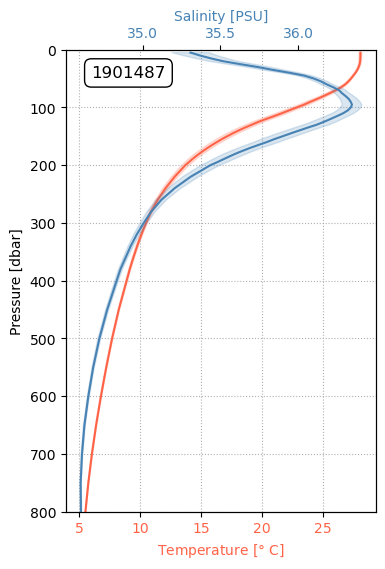

In [6]:
tropic_temp = ds29.temperature
tropic_sal = ds29.salinity
tropic_pressure = ds29.pressure

n_temp = tropic_temp.count(dim='time')
n_sal = tropic_sal.count(dim='time')
temp_std = tropic_temp.std(dim='time')
sal_std = tropic_sal.std(dim='time')
temp_se = temp_std / np.sqrt(n_temp)
sal_se = sal_std / np.sqrt(n_sal)
temp_conf = 1.96 * temp_se
sal_conf = 1.96 * sal_se

fig, ax1 = plt.subplots(figsize=(4, 6))

color = 'tomato'
ax1.plot(tropic_temp.mean(dim='time'), tropic_pressure, color=color, label='Temperature')
ax1.set_xlabel('Temperature [$\degree$ C]', color=color)
ax1.set_ylabel('Pressure [dbar]')
ax1.set_ylim([0, 800])
ax1.invert_yaxis()
ax1.tick_params(axis='x', labelcolor=color)
ax1.grid(ls='dotted', which='both')

ax1.fill_betweenx(
    tropic_pressure,
    tropic_temp.mean(dim='time') - temp_conf,
    tropic_temp.mean(dim='time') + temp_conf,
    color='tomato',
    alpha=0.2
)

# instantiate a second axes that shares the same y-axis
ax2 = ax1.twiny()
color = 'steelblue'
ax2.plot(tropic_sal.mean(dim='time'), tropic_pressure, color=color, label='Salinity')
ax2.set_xlabel('Salinity [PSU]', color=color)
ax2.tick_params(axis='x', labelcolor=color)

ax2.fill_betweenx(
    tropic_pressure,
    tropic_sal.mean(dim='time') - sal_conf,
    tropic_sal.mean(dim='time') + sal_conf,
    color='steelblue',
    alpha=0.2
)

ax1.text(
    6.0, 48,
    '1901487',
    fontsize=12,
    bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.4')
)

## Part III
### Task 3.1- Reading and processing climatology data

In [7]:
ds = xr.open_dataset("/home/cjcin/GPGN268/coursework-carlson/ds02-global-warming/RG_ArgoClim_Temperature_2019.nc", decode_times=False)
t0 = np.datetime64("2004-01")
months = range(len(ds.TIME))
time = np.array([t0 + np.timedelta64(m, "M") for m in months])

The error occurs because the time unit in the data is "months since 2004-01-01 00:00:00" which is a unit that the default calendar cannot handle. We have to pass decode_times=False into the open_dataset() function.

In [8]:
ds = ds.rename({'TIME':'time'})
ds = ds.rename({'ARGO_TEMPERATURE_MEAN':'temp_mean',
                'ARGO_TEMPERATURE_ANOMALY':'temp_anom',
                'PRESSURE':'pressure',
                'LATITUDE':'latitude',
                'LONGITUDE':'longitude'})
# Replace the old values with the time array that we created
ds['time'] = time

In [9]:
print(ds)

<xarray.Dataset> Size: 2GB
Dimensions:          (pressure: 58, latitude: 145, longitude: 360, time: 180)
Coordinates:
  * pressure         (pressure) float32 232B 2.5 10.0 20.0 ... 1.9e+03 1.975e+03
  * latitude         (latitude) float32 580B -64.5 -63.5 -62.5 ... 78.5 79.5
  * longitude        (longitude) float32 1kB 20.5 21.5 22.5 ... 378.5 379.5
  * time             (time) datetime64[s] 1kB 2004-01-01 ... 2018-12-01
Data variables:
    temp_mean        (pressure, latitude, longitude) float32 12MB ...
    temp_anom        (time, pressure, latitude, longitude) float32 2GB ...
    BATHYMETRY_MASK  (pressure, latitude, longitude) float32 12MB ...
    MAPPING_MASK     (pressure, latitude, longitude) float32 12MB ...


This is ocean temperature data mapped over time. It is collected using the ARGO floats, which yield temperature, salinity, and velocity. The structure represents ocean vitals.

I tried for an hour but was unable to get hvplot to install correctly and satisfy dependencies.

In [10]:
# import hvplot.xarray

# depth_ave_temp = ds.temp_anom.mean(dim='pressure')
# depth_ave_temp.hvplot('longitude', 'latitude', cmap='RdBu_r', clim=(-3, 3))

### 3.2- Seasonal Averages

In [11]:
depth_ave_temp = ds.temp_anom.mean(dim='pressure')
seasonal_temp = depth_ave_temp.groupby("time.season").mean()

<>:25: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:25: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
/tmp/ipykernel_2912/1067759668.py:25: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  cbar = plt.colorbar(cs, cax=cax,label='Temperature Anomaly [$\degree$C]')


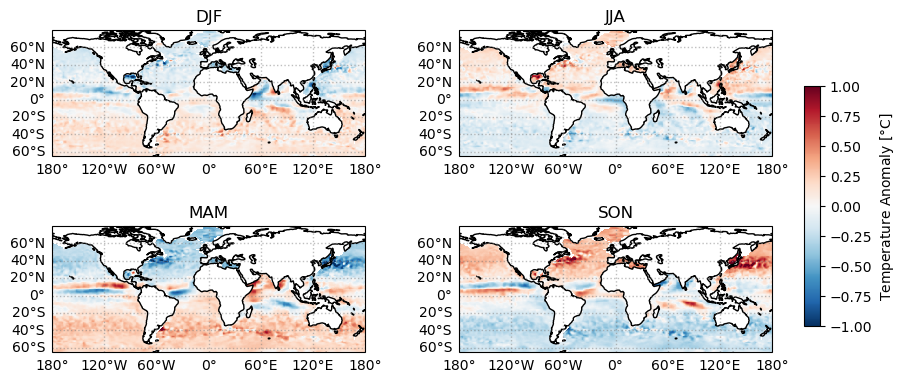

In [14]:
vmin = -1
vmax = 1
# Creates four subplots (2 rows and 2 columns)
fig, axes = plt.subplots(2, 2, figsize=(8, 6), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, s in enumerate(seasonal_temp.season):
    ax = axes[i]
    cs = ax.pcolormesh(seasonal_temp.longitude,
                        seasonal_temp.latitude,
                        seasonal_temp.sel(season=s),
                        transform = ccrs.PlateCarree(),
                        vmin=vmin,vmax=vmax,cmap='RdBu_r')
    ax.set_title("{}".format(s.values))
    ax.coastlines()
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=1, color='gray',
                  alpha=0.5, linestyle='dotted')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 10}
    gl.ylabel_style = {'size': 10}

cax = fig.add_axes([0.99, 0.35, 0.02, 0.4])
cbar = plt.colorbar(cs, cax=cax,label='Temperature Anomaly [$\degree$C]')
fig.subplots_adjust(bottom=0.25, top=0.9, left=0.05, right=0.95,
                    wspace=0.3, hspace=0.01)

The variable `seasonal_temp` holds mmean temperature data against latitude and longitude for all four seasons. The maps show how each season affects the average ocean temperatures across the world.

In the Northern Hemisphere, the oceans are the coldest at the end of Winter, in the months of March, April, and May. Some areas that experience especially significant cooling during this period are the seas on both sides of Japan, the Northwestern Atlantic, and interestingly, a few areas very close to the equator, likely due to ocean currents. In the Northern Hemisphere Summer, the Caribbean and the waters around Luzon experience the most significant changes in ocean temperature.

### Task 3.3- Ocean Warming

<>:42: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:42: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
/tmp/ipykernel_2912/1226548487.py:42: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  cbar = plt.colorbar(cs, cax=cax,label='Temperature Anomaly [$\degree$C]')
/home/cjcin/miniconda3/envs/GPGN268/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/cjcin/miniconda3/envs/GPGN268/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,

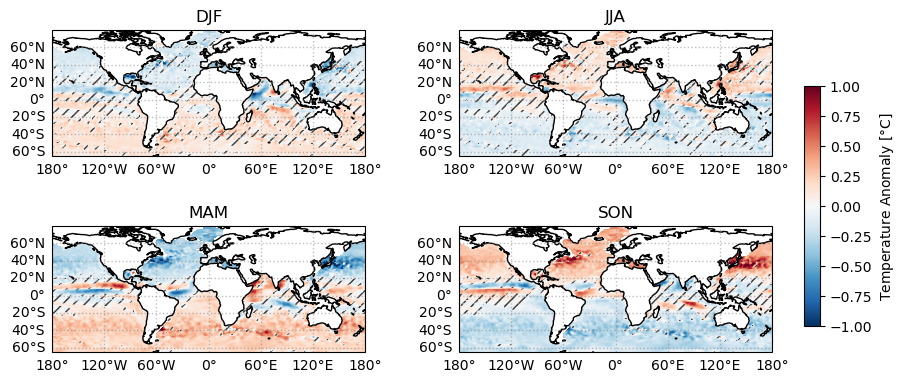

In [25]:
seasonal_std = depth_ave_temp.groupby("time.season").std(dim="time")
seasonal_n = depth_ave_temp.groupby("time.season").count(dim="time")
seasonal_se = seasonal_std / np.sqrt(seasonal_n)
z_score = seasonal_temp / seasonal_se
not_significant = np.abs(z_score) < 1.96

fig, axes = plt.subplots(2, 2, figsize=(8, 6), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, s in enumerate(seasonal_temp.season):
    ax = axes[i]
    cs = ax.pcolormesh(seasonal_temp.longitude,
                        seasonal_temp.latitude,
                        seasonal_temp.sel(season=s),
                        transform = ccrs.PlateCarree(),
                        vmin=vmin,vmax=vmax,cmap='RdBu_r')
    
    mask = not_significant.sel(season=s)
    mask_plot = mask.where(mask)
    
    er = ax.pcolor(seasonal_temp.longitude,
                        seasonal_temp.latitude,
                        mask_plot,
                        hatch='///',
                        alpha=0.0,
                        transform=ccrs.PlateCarree()
    )

    ax.set_title("{}".format(s.values))
    ax.coastlines()

    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=1, color='gray',
                  alpha=0.5, linestyle='dotted')
    
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 10}
    gl.ylabel_style = {'size': 10}

cax = fig.add_axes([0.99, 0.35, 0.02, 0.4])
cbar = plt.colorbar(cs, cax=cax,label='Temperature Anomaly [$\degree$C]')
fig.subplots_adjust(bottom=0.25, top=0.9, left=0.05, right=0.95,
                    wspace=0.3, hspace=0.01)


The plot above shows areas where the oceans fluctuate with the seasons beyond a level accepted to be statistically significant. Areas of significant difference are not hatched. This analysis depends on the assumption that measurements in time are independent. That assumption is likely flawed, since one warm month in one area usually indicates another warm month in the same area. A better method would be one that analyzes temperature data by taking months into account as groups, which might show more areas that don't appear statistically significant.

### Task 3.4- Hypothesis testing about seasonal averages

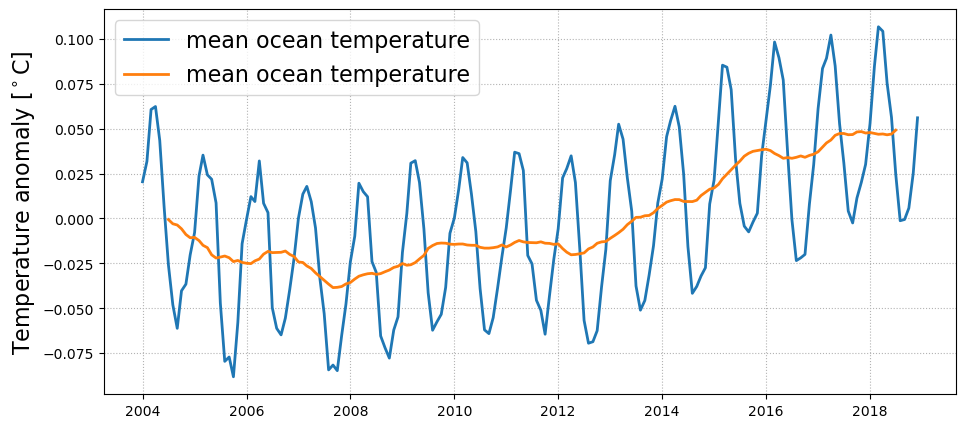

In [19]:
global_mean = depth_ave_temp.mean(dim=['latitude', 'longitude'])
running_mean = global_mean.rolling(time=12, center=True).mean()

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(
    global_mean.time,
    global_mean,
    linewidth=2,
    label='mean ocean temperature'
)

ax.plot(
    running_mean.time,
    running_mean,
    linewidth=2,
    label='mean ocean temperature'
)

ax.set_ylabel("Temperature anomaly [$^\\circ$C]", fontsize=16)
ax.grid(True, linestyle=':', color='0.7')
ax.legend(loc='upper left',
          fontsize=16)

The average change in temperature anomaly per year between 2012 and 2018 is about 0.0105 $\degree$ C per year, or 0.105 $\degree$ C per decade. According to NOAA, global warming has been about 0.20 $\degree$ C per decade on average since 1982. That disparity could be attributed to the massive thermal mass of the ocean which prevents it from warming as fast as the atmosphere.